In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("01_data/processed/nhanes_analytic_clean.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Create total condition flags (diagnosed OR undiagnosed) ──
df["has_diabetes"] = (
    (df["told_diabetic"] == 1) |
    (df["undiagnosed_diabetes"] == 1)
).astype(int)

df["has_prediabetes"] = (
    df["undiagnosed_prediabetes"] == 1
).astype(int)

df["has_hypertension"] = (
    (df["told_hypertensive"] == 1) |
    (df["undiagnosed_hypertension"] == 1)
).astype(int)

df["has_hyperlipidemia"] = (
    (df["told_high_cholesterol"] == 1) |
    (df["undiagnosed_hyperlipidemia"] == 1)
).astype(int)

# ── Comorbidity pair flags ──
df["diabetes_hypertension"]     = ((df["has_diabetes"]==1) & (df["has_hypertension"]==1)).astype(int)
df["diabetes_hyperlipidemia"]   = ((df["has_diabetes"]==1) & (df["has_hyperlipidemia"]==1)).astype(int)
df["hypertension_hyperlipidemia"]= ((df["has_hypertension"]==1) & (df["has_hyperlipidemia"]==1)).astype(int)
df["prediabetes_hypertension"]  = ((df["has_prediabetes"]==1) & (df["has_hypertension"]==1)).astype(int)
df["prediabetes_hyperlipidemia"]= ((df["has_prediabetes"]==1) & (df["has_hyperlipidemia"]==1)).astype(int)

# ── Triple comorbidity — Metabolic Syndrome proxy ──
df["metabolic_syndrome"] = (
    (df["has_diabetes"] == 1) &
    (df["has_hypertension"] == 1) &
    (df["has_hyperlipidemia"] == 1)
).astype(int)

# ── Total condition burden ──
df["total_burden"] = (
    df["has_diabetes"] +
    df["has_prediabetes"] +
    df["has_hypertension"] +
    df["has_hyperlipidemia"]
)

# ── Verify ──
print("\nCondition Prevalence:")
conditions = {
    "Diabetes (any)":         "has_diabetes",
    "Prediabetes":            "has_prediabetes",
    "Hypertension (any)":     "has_hypertension",
    "Hyperlipidemia (any)":   "has_hyperlipidemia",
    "Diabetes + Hypertension":"diabetes_hypertension",
    "Diabetes + Hyperlipidemia":"diabetes_hyperlipidemia",
    "Hypertension + Hyperlipidemia":"hypertension_hyperlipidemia",
    "Metabolic Syndrome (all 3)":"metabolic_syndrome"
}
for label, col in conditions.items():
    n = df[col].sum()
    pct = df[col].mean() * 100
    print(f"  {label:40s}: {n:,} ({pct:.1f}%)")

Loaded: 5,992 rows × 37 columns

Condition Prevalence:
  Diabetes (any)                          : 1,015 (16.9%)
  Prediabetes                             : 1,389 (23.2%)
  Hypertension (any)                      : 3,520 (58.7%)
  Hyperlipidemia (any)                    : 3,557 (59.4%)
  Diabetes + Hypertension                 : 830 (13.9%)
  Diabetes + Hyperlipidemia               : 767 (12.8%)
  Hypertension + Hyperlipidemia           : 2,404 (40.1%)
  Metabolic Syndrome (all 3)              : 638 (10.6%)


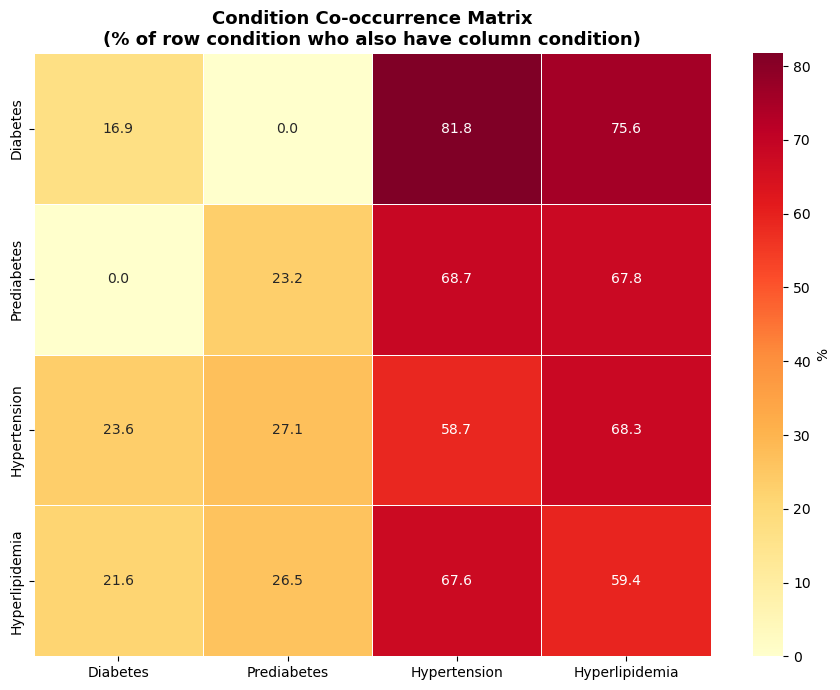

Co-occurrence matrix saved.


In [2]:
# ── Co-occurrence heatmap ──
cond_cols   = ["has_diabetes", "has_prediabetes",
               "has_hypertension", "has_hyperlipidemia"]
cond_labels = ["Diabetes", "Prediabetes",
               "Hypertension", "Hyperlipidemia"]

cooccurrence = pd.DataFrame(index=cond_labels, columns=cond_labels, dtype=float)
for i, c1 in enumerate(cond_cols):
    for j, c2 in enumerate(cond_cols):
        if i == j:
            cooccurrence.iloc[i,j] = df[c1].mean() * 100
        else:
            # % of people with c1 who ALSO have c2
            mask = df[c1] == 1
            cooccurrence.iloc[i,j] = df.loc[mask, c2].mean() * 100

plt.figure(figsize=(9, 7))
sns.heatmap(cooccurrence.astype(float),
            annot=True, fmt=".1f",
            cmap="YlOrRd",
            linewidths=0.5,
            cbar_kws={"label": "%"})
plt.title("Condition Co-occurrence Matrix\n(% of row condition who also have column condition)",
          fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("01_data/processed/comorbidity_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Co-occurrence matrix saved.")

Utilization by Total Condition Burden:
 total_burden    n  er_rate_pct  hosp_rate_pct
            0 1089         23.0           18.8
            1 1644         18.7           17.4
            2 1940         19.4           13.5
            3 1319         18.7           13.9


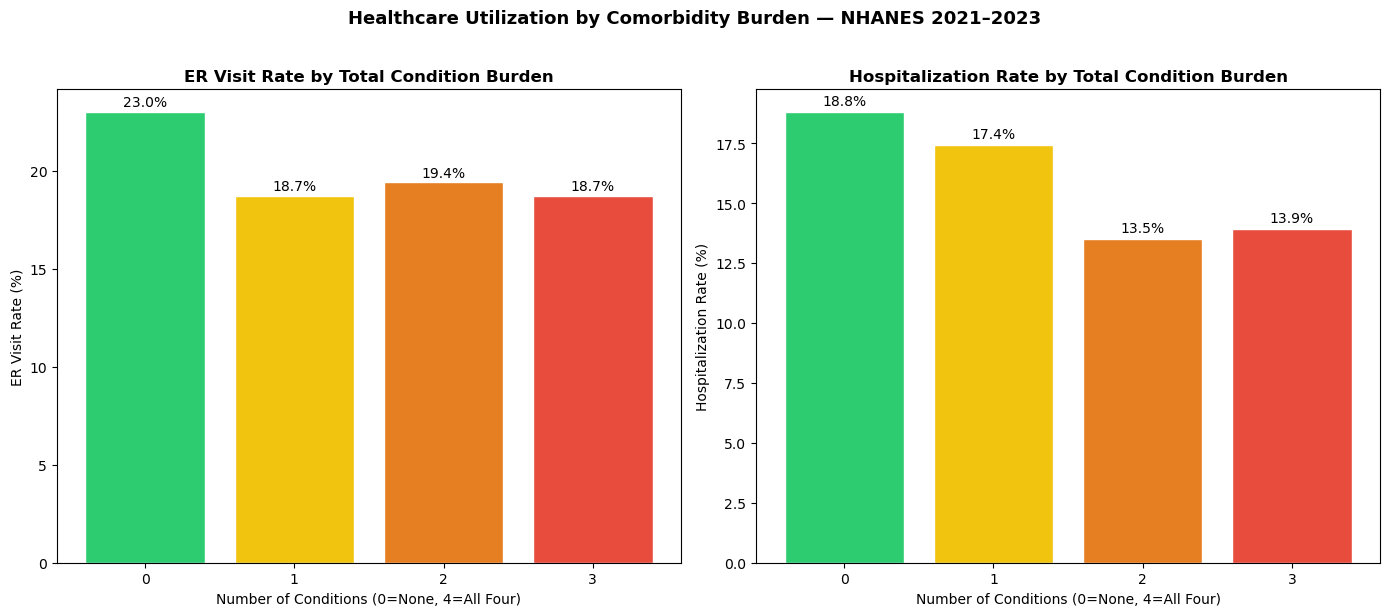

Burden utilization chart saved.


In [3]:
# ── Utilization by total condition burden ──
burden_util = df.groupby("total_burden").agg(
    n             = ("id", "count"),
    er_rate       = ("er_visit_binary", "mean"),
    hosp_rate     = ("hosp_binary", "mean")
).reset_index()

burden_util["er_rate_pct"]   = (burden_util["er_rate"]   * 100).round(1)
burden_util["hosp_rate_pct"] = (burden_util["hosp_rate"] * 100).round(1)

print("Utilization by Total Condition Burden:")
print(burden_util[["total_burden","n","er_rate_pct","hosp_rate_pct"]].to_string(index=False))

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ["#2ecc71","#f1c40f","#e67e22","#e74c3c","#8e44ad"]

axes[0].bar(burden_util["total_burden"].astype(str),
            burden_util["er_rate_pct"],
            color=colors[:len(burden_util)], edgecolor="white")
axes[0].set_title("ER Visit Rate by Total Condition Burden",
                  fontweight="bold")
axes[0].set_xlabel("Number of Conditions (0=None, 4=All Four)")
axes[0].set_ylabel("ER Visit Rate (%)")
for i, v in enumerate(burden_util["er_rate_pct"]):
    axes[0].text(i, v + 0.3, f"{v}%", ha="center", fontsize=10)

axes[1].bar(burden_util["total_burden"].astype(str),
            burden_util["hosp_rate_pct"],
            color=colors[:len(burden_util)], edgecolor="white")
axes[1].set_title("Hospitalization Rate by Total Condition Burden",
                  fontweight="bold")
axes[1].set_xlabel("Number of Conditions (0=None, 4=All Four)")
axes[1].set_ylabel("Hospitalization Rate (%)")
for i, v in enumerate(burden_util["hosp_rate_pct"]):
    axes[1].text(i, v + 0.3, f"{v}%", ha="center", fontsize=10)

plt.suptitle("Healthcare Utilization by Comorbidity Burden — NHANES 2021–2023",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("01_data/processed/comorbidity_burden_utilization.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Burden utilization chart saved.")


Comorbidity Pattern Outcomes:
           Comorbidity Pattern    N  ER Visit Rate (%)  Hosp Rate (%)
                 No Conditions 1089               23.0           18.8
                 Diabetes Only   56               16.1           10.7
             Hypertension Only  924               22.2           14.3
           Hyperlipidemia Only 1024               15.3           18.1
       Diabetes + Hypertension  192               19.3           15.1
     Diabetes + Hyperlipidemia  129               25.6           17.8
 Hypertension + Hyperlipidemia 1766               18.2           13.4
All Three (Metabolic Syndrome)  638               19.9           15.7


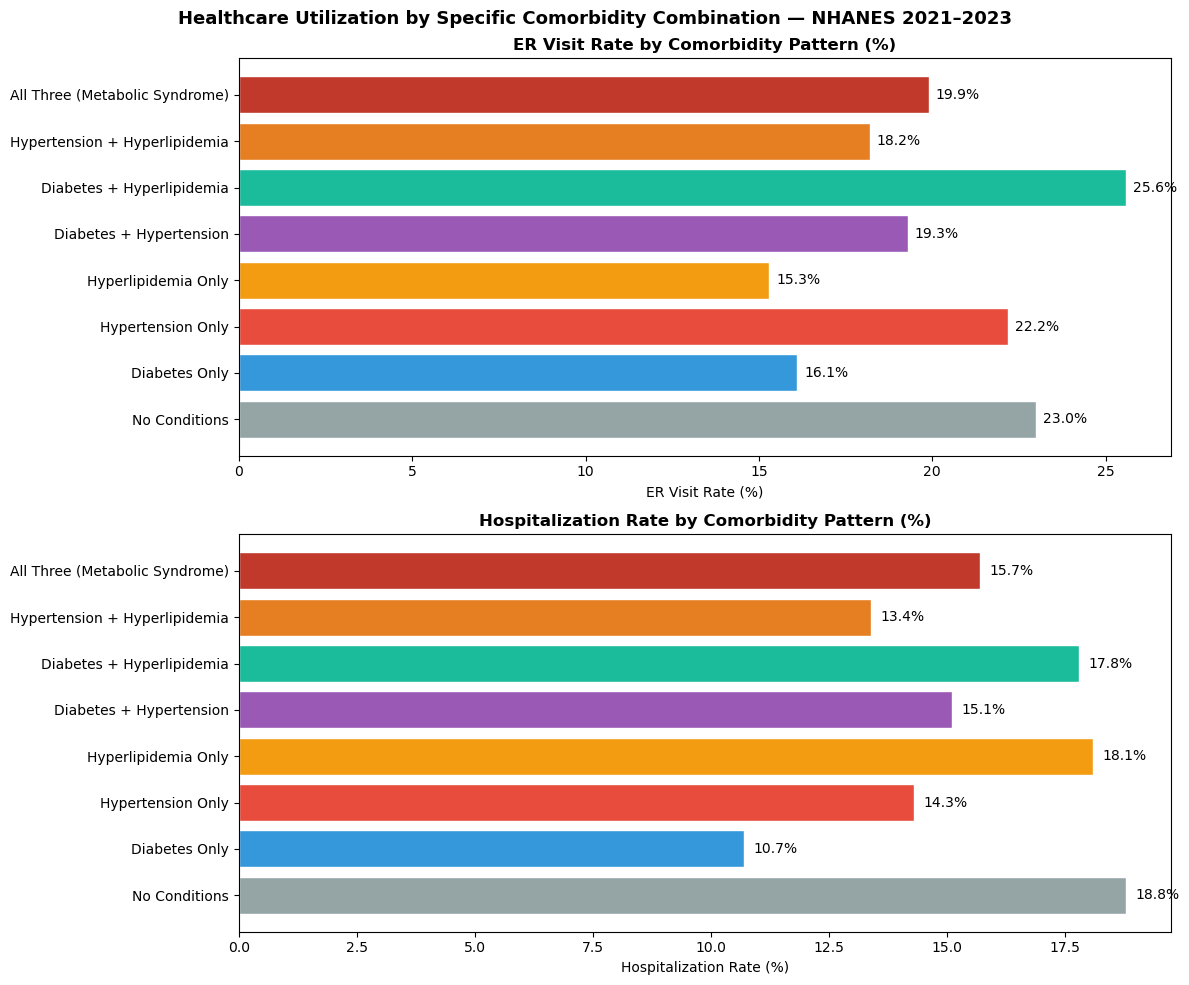

Comorbidity pair outcomes chart saved.


In [4]:
# ── Comorbidity pair outcomes ──
pairs = {
    "No Conditions":               df["total_burden"] == 0,
    "Diabetes Only":               (df["has_diabetes"]==1) & (df["has_hypertension"]==0) & (df["has_hyperlipidemia"]==0),
    "Hypertension Only":           (df["has_hypertension"]==1) & (df["has_diabetes"]==0) & (df["has_hyperlipidemia"]==0),
    "Hyperlipidemia Only":         (df["has_hyperlipidemia"]==1) & (df["has_diabetes"]==0) & (df["has_hypertension"]==0),
    "Diabetes + Hypertension":     (df["diabetes_hypertension"]==1) & (df["has_hyperlipidemia"]==0),
    "Diabetes + Hyperlipidemia":   (df["diabetes_hyperlipidemia"]==1) & (df["has_hypertension"]==0),
    "Hypertension + Hyperlipidemia":(df["hypertension_hyperlipidemia"]==1) & (df["has_diabetes"]==0),
    "All Three (Metabolic Syndrome)":(df["metabolic_syndrome"]==1)
}

results = []
for label, mask in pairs.items():
    subset = df[mask]
    if len(subset) > 10:
        results.append({
            "Comorbidity Pattern":  label,
            "N":                    len(subset),
            "ER Visit Rate (%)":    round(subset["er_visit_binary"].mean() * 100, 1),
            "Hosp Rate (%)":        round(subset["hosp_binary"].mean() * 100, 1)
        })

results_df = pd.DataFrame(results)
print("\nComorbidity Pattern Outcomes:")
print(results_df.to_string(index=False))

# ── Plot ──
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

colors_bar = ["#95a5a6","#3498db","#e74c3c","#f39c12",
              "#9b59b6","#1abc9c","#e67e22","#c0392b"]

axes[0].barh(results_df["Comorbidity Pattern"],
             results_df["ER Visit Rate (%)"],
             color=colors_bar[:len(results_df)], edgecolor="white")
axes[0].set_title("ER Visit Rate by Comorbidity Pattern (%)",
                  fontweight="bold", fontsize=12)
axes[0].set_xlabel("ER Visit Rate (%)")
for i, v in enumerate(results_df["ER Visit Rate (%)"]):
    axes[0].text(v + 0.2, i, f"{v}%", va="center", fontsize=10)

axes[1].barh(results_df["Comorbidity Pattern"],
             results_df["Hosp Rate (%)"],
             color=colors_bar[:len(results_df)], edgecolor="white")
axes[1].set_title("Hospitalization Rate by Comorbidity Pattern (%)",
                  fontweight="bold", fontsize=12)
axes[1].set_xlabel("Hospitalization Rate (%)")
for i, v in enumerate(results_df["Hosp Rate (%)"]):
    axes[1].text(v + 0.2, i, f"{v}%", va="center", fontsize=10)

plt.suptitle("Healthcare Utilization by Specific Comorbidity Combination — NHANES 2021–2023",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("01_data/processed/comorbidity_pair_outcomes.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Comorbidity pair outcomes chart saved.")

In [5]:
# ── Metabolic syndrome profile ──
ms = df[df["metabolic_syndrome"] == 1]
no_ms = df[df["metabolic_syndrome"] == 0]

print("=" * 55)
print("METABOLIC SYNDROME PROFILE (All Three Conditions)")
print("=" * 55)
print(f"Total with Metabolic Syndrome: {len(ms):,} ({len(ms)/len(df)*100:.1f}%)")
print(f"\nER Visit Rate:")
print(f"  Metabolic Syndrome:  {ms['er_visit_binary'].mean()*100:.1f}%")
print(f"  No Metabolic Syndrome: {no_ms['er_visit_binary'].mean()*100:.1f}%")
print(f"\nHospitalization Rate:")
print(f"  Metabolic Syndrome:  {ms['hosp_binary'].mean()*100:.1f}%")
print(f"  No Metabolic Syndrome: {no_ms['hosp_binary'].mean()*100:.1f}%")
print(f"\nDemographic Profile:")
print(f"  Mean Age:            {ms['age'].mean():.1f} vs {no_ms['age'].mean():.1f} (no MS)")
print(f"  Mean BMI:            {ms['bmi'].mean():.1f} vs {no_ms['bmi'].mean():.1f} (no MS)")
print(f"  Mean HbA1c:          {ms['hba1c'].mean():.2f} vs {no_ms['hba1c'].mean():.2f} (no MS)")
print(f"  Mean Systolic BP:    {ms['systolic_bp'].mean():.1f} vs {no_ms['systolic_bp'].mean():.1f} (no MS)")
print(f"  Uninsured Rate:      {(ms['has_insurance']==0).mean()*100:.1f}% vs {(no_ms['has_insurance']==0).mean()*100:.1f}% (no MS)")
print(f"\nRace/Ethnicity Distribution:")
print(ms["race_ethnicity"].value_counts(normalize=True).mul(100).round(1))

METABOLIC SYNDROME PROFILE (All Three Conditions)
Total with Metabolic Syndrome: 638 (10.6%)

ER Visit Rate:
  Metabolic Syndrome:  19.9%
  No Metabolic Syndrome: 19.7%

Hospitalization Rate:
  Metabolic Syndrome:  15.7%
  No Metabolic Syndrome: 15.6%

Demographic Profile:
  Mean Age:            64.0 vs 52.9 (no MS)
  Mean BMI:            33.0 vs 29.4 (no MS)
  Mean HbA1c:          7.35 vs 5.59 (no MS)
  Mean Systolic BP:    130.2 vs 122.3 (no MS)
  Uninsured Rate:      4.2% vs 8.8% (no MS)

Race/Ethnicity Distribution:
race_ethnicity
Non-Hispanic White    49.8
Non-Hispanic Black    16.6
Other Hispanic        11.8
Mexican American       8.2
Other/Multiracial      7.8
Non-Hispanic Asian     5.8
Name: proportion, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
import shap

# ── Original features + comorbidity interaction features ──
original_features = [
    "age", "poverty_income_ratio", "education",
    "hba1c", "systolic_bp", "diastolic_bp",
    "total_cholesterol", "bmi", "waist_circumference",
    "undiagnosed_diabetes", "undiagnosed_prediabetes",
    "undiagnosed_hypertension", "undiagnosed_hyperlipidemia",
    "composite_risk_score", "has_insurance",
    "usual_care_site", "outpatient_visits",
    "gender_encoded", "race_encoded", "health_encoded"
]

# New comorbidity features
comorbidity_features = [
    "has_diabetes", "has_hypertension", "has_hyperlipidemia",
    "diabetes_hypertension", "diabetes_hyperlipidemia",
    "hypertension_hyperlipidemia", "metabolic_syndrome",
    "total_burden"
]

# Encode gender and health if not already in df
if "gender_encoded" not in df.columns:
    df["gender_encoded"] = df["gender"].map({"Male":0, "Female":1})
if "race_encoded" not in df.columns:
    df["race_encoded"] = df["race_ethnicity"].map({
        "Non-Hispanic White":0, "Non-Hispanic Black":1,
        "Mexican American":2, "Other Hispanic":3,
        "Non-Hispanic Asian":4, "Other/Multiracial":5})
if "health_encoded" not in df.columns:
    df["health_encoded"] = pd.to_numeric(df["self_rated_health"], errors="coerce")

all_features = original_features + comorbidity_features
target = "er_visit_binary"

model_df = df[all_features + [target]].dropna()
X = model_df[all_features]
y = model_df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Train upgraded Random Forest
rf_upgraded = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1)
rf_upgraded.fit(X_train_sm, y_train_sm)

# Evaluate
y_prob = rf_upgraded.predict_proba(X_test)[:, 1]
auc_upgraded = roc_auc_score(y_test, y_prob)

print("=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
print(f"Original Random Forest AUC:  0.709")
print(f"Upgraded RF with Comorbidity: {auc_upgraded:.3f}")
print(f"AUC Improvement: {(auc_upgraded - 0.709):.3f}")

report = classification_report(y_test, rf_upgraded.predict(X_test),
                                output_dict=True)
print(f"\nUpgraded Model Performance:")
print(f"  F1 Score:  {report['weighted avg']['f1-score']:.3f}")
print(f"  Precision: {report['weighted avg']['precision']:.3f}")
print(f"  Recall:    {report['weighted avg']['recall']:.3f}")

MODEL COMPARISON
Original Random Forest AUC:  0.709
Upgraded RF with Comorbidity: 0.709
AUC Improvement: -0.000

Upgraded Model Performance:
  F1 Score:  0.749
  Precision: 0.737
  Recall:    0.787


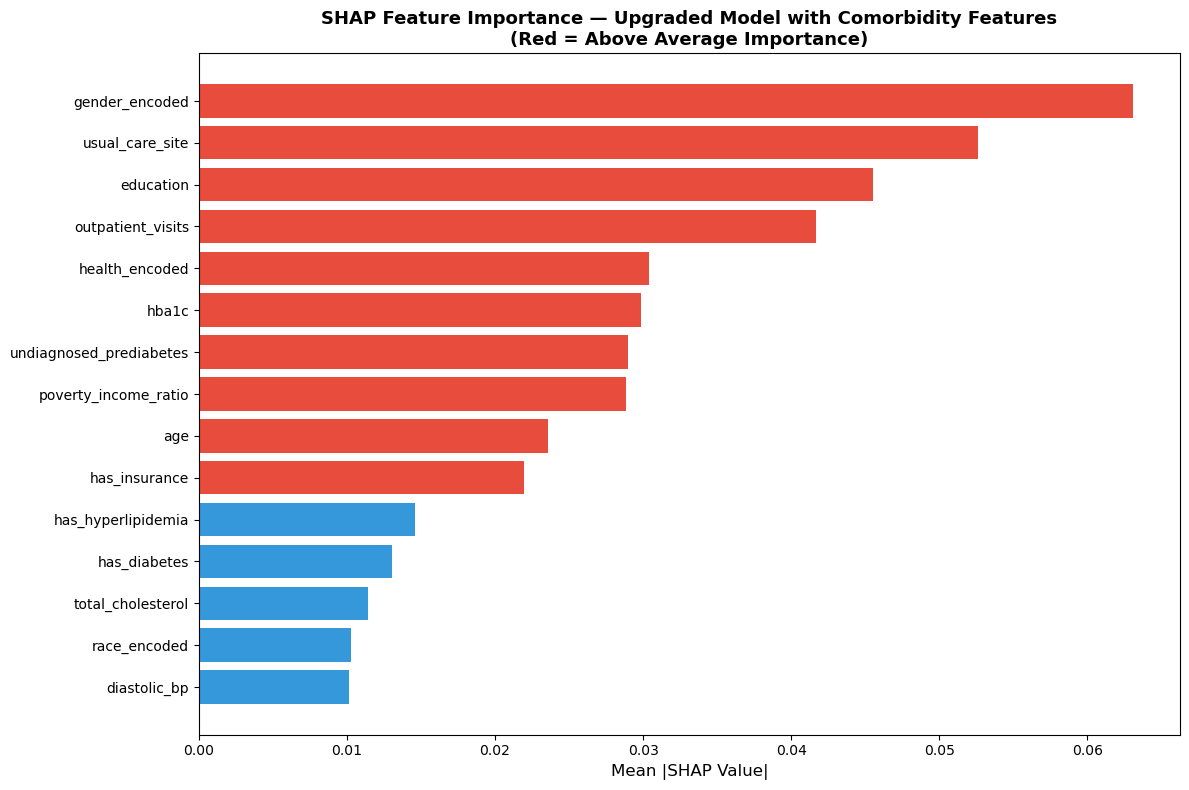


Top 10 Features in Upgraded Model:
   1. gender_encoded                          : 0.0631
   2. usual_care_site                         : 0.0526
   3. education                               : 0.0455
   4. outpatient_visits                       : 0.0416
   5. health_encoded                          : 0.0304
   6. hba1c                                   : 0.0298
   7. undiagnosed_prediabetes                 : 0.0290
   8. poverty_income_ratio                    : 0.0289
   9. age                                     : 0.0236
  10. has_insurance                           : 0.0220


In [7]:
# ── SHAP on upgraded model ──
explainer   = shap.TreeExplainer(rf_upgraded)
shap_values = explainer.shap_values(X_test)
shap_vals   = shap_values[:, :, 1]

# Mean absolute SHAP
shap_df    = pd.DataFrame(shap_vals, columns=all_features)
mean_shap  = shap_df.abs().mean().sort_values(ascending=True)

# ── Plot top 15 features ──
top15 = mean_shap.tail(15)
colors_shap = ["#e74c3c" if x > mean_shap.mean()
               else "#3498db" for x in top15.values]

plt.figure(figsize=(12, 8))
plt.barh(top15.index, top15.values, color=colors_shap)
plt.xlabel("Mean |SHAP Value|", fontsize=12)
plt.title("SHAP Feature Importance — Upgraded Model with Comorbidity Features\n(Red = Above Average Importance)",
          fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("01_data/processed/comorbidity_shap_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 Features in Upgraded Model:")
for i, (feat, val) in enumerate(mean_shap.sort_values(ascending=False).head(10).items()):
    print(f"  {i+1:2d}. {feat:40s}: {val:.4f}")

In [9]:
import pandas as pd
import numpy as np

# Create missing columns
df["age_group"] = pd.cut(
    df["age"],
    bins=[19, 39, 59, 80],
    labels=["20-39", "40-59", "60-80"]
).astype(str)

df["insurance_status"] = df["has_insurance"].map({1: "Insured", 0: "Uninsured"})

# Now run the export
tableau_comorbidity = df[[
    "id", "age", "age_group", "gender", "race_ethnicity",
    "income_group", "insurance_status",
    "has_diabetes", "has_hypertension", "has_hyperlipidemia", "has_prediabetes",
    "diabetes_hypertension", "diabetes_hyperlipidemia",
    "hypertension_hyperlipidemia", "metabolic_syndrome",
    "total_burden", "risk_tier",
    "er_visit_binary", "hosp_binary"
]].copy()

def get_pattern(row):
    if row["total_burden"] == 0:
        return "No Conditions"
    elif row["metabolic_syndrome"] == 1:
        return "All Three (Metabolic Syndrome)"
    elif row["diabetes_hypertension"] == 1 and row["has_hyperlipidemia"] == 0:
        return "Diabetes + Hypertension"
    elif row["diabetes_hyperlipidemia"] == 1 and row["has_hypertension"] == 0:
        return "Diabetes + Hyperlipidemia"
    elif row["hypertension_hyperlipidemia"] == 1 and row["has_diabetes"] == 0:
        return "Hypertension + Hyperlipidemia"
    elif row["has_diabetes"] == 1:
        return "Diabetes Only"
    elif row["has_hypertension"] == 1:
        return "Hypertension Only"
    elif row["has_hyperlipidemia"] == 1:
        return "Hyperlipidemia Only"
    elif row["has_prediabetes"] == 1:
        return "Prediabetes Only"
    else:
        return "Other"

tableau_comorbidity["comorbidity_pattern"] = tableau_comorbidity.apply(get_pattern, axis=1)

tableau_comorbidity.to_csv("01_data/processed/nhanes_comorbidity_tableau.csv", index=False)
print(f"✅ Saved: {tableau_comorbidity.shape[0]:,} rows")
print(f"\nComorbidity pattern distribution:")
print(tableau_comorbidity["comorbidity_pattern"].value_counts())

✅ Saved: 5,992 rows

Comorbidity pattern distribution:
comorbidity_pattern
Hypertension + Hyperlipidemia     1766
No Conditions                     1089
Hyperlipidemia Only               1024
Hypertension Only                  924
All Three (Metabolic Syndrome)     638
Diabetes + Hypertension            192
Prediabetes Only                   174
Diabetes + Hyperlipidemia          129
Diabetes Only                       56
Name: count, dtype: int64
